<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Categorical features Encoding ....
<a class="anchor" id="1"></a> 

<img src="https://i.ibb.co/dt2WbnJ/data-Srt-Enconding.jpg" width=400></img>
- Data loading 
- Data Encoding
- Data Cleaning
- feature importance 

In [86]:

# dataset loading 
import pandas as pd
# read_csv(..., nrows=999999)
df= pd.read_csv("../data/HousePrice4.csv", index_col=0)


![](../imgs/featureEngin.png)

In [87]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,ScreenPorch,PoolArea,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,Remodeled,Age,Isnew
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,3,Lvl,AllPub,Inside,2,...,0,0,0,2,WD,Normal,208500,0,5,0
2,20,RL,80.0,9600,Pave,3,Lvl,AllPub,FR2,2,...,0,0,0,5,WD,Normal,181500,0,31,0
3,60,RL,68.0,11250,Pave,2,Lvl,AllPub,Inside,2,...,0,0,0,9,WD,Normal,223500,1,6,0
4,70,RL,60.0,9550,Pave,2,Lvl,AllPub,Corner,2,...,0,0,0,2,WD,Abnorml,140000,1,36,0
5,60,RL,84.0,14260,Pave,2,Lvl,AllPub,FR2,2,...,0,0,0,12,WD,Normal,250000,0,8,0


In [88]:
df.select_dtypes(exclude="number").columns # select non-numeric columns

Index(['MSZoning', 'Street', 'LandContour', 'Utilities', 'LotConfig',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Foundation', 'Heating',
       'Electrical', 'GarageType', 'SaleType', 'SaleCondition'],
      dtype='object')

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 71 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   int64  
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   int64  
 10  Neighborhood   1460 non-null   int64  
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  RoofStyle      1460 non-null   object 
 18  RoofMatl     

###   Features Imputation 

In [90]:
# missing higest 10  lagest  missing values 
(df.isnull().sum()/df.shape[0]).sort_values(ascending=False).head(15)

LotFrontage     0.177397
GarageFinish    0.055479
GarageCond      0.055479
GarageQual      0.055479
GarageType      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtFinType1    0.025342
BsmtCond        0.025342
BsmtQual        0.025342
MasVnrArea      0.005479
Electrical      0.000685
MSSubClass      0.000000
MSZoning        0.000000
LotArea         0.000000
dtype: float64

In [91]:
# display features names having  highest missing values 
(df.isnull().sum()/df.shape[0]).sort_values(ascending=False).head(12)

LotFrontage     0.177397
GarageFinish    0.055479
GarageCond      0.055479
GarageQual      0.055479
GarageType      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtFinType1    0.025342
BsmtCond        0.025342
BsmtQual        0.025342
MasVnrArea      0.005479
Electrical      0.000685
dtype: float64

In [92]:
miss_features= (df.isnull().sum()/df.shape[0]).sort_values(ascending=False).head(12).index 
miss_features

Index(['LotFrontage', 'GarageFinish', 'GarageCond', 'GarageQual', 'GarageType',
       'BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtCond', 'BsmtQual',
       'MasVnrArea', 'Electrical'],
      dtype='object')

In [ ]:
imputer_num_cols= df[miss_features].select_dtypes("number").columns
df[imputer_num_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LotFrontage   1201 non-null   float64
 1   GarageFinish  1379 non-null   float64
 2   GarageCond    1379 non-null   float64
 3   GarageQual    1379 non-null   float64
 4   BsmtFinType2  1422 non-null   float64
 5   BsmtExposure  1422 non-null   float64
 6   BsmtFinType1  1423 non-null   float64
 7   BsmtCond      1423 non-null   float64
 8   BsmtQual      1423 non-null   float64
 9   MasVnrArea    1452 non-null   float64
dtypes: float64(10)
memory usage: 125.5 KB


In [94]:
imputer_cat_cols= df[miss_features].select_dtypes(exclude="number").columns
df[imputer_cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   GarageType  1379 non-null   object
 1   Electrical  1459 non-null   object
dtypes: object(2)
memory usage: 34.2+ KB


In [103]:
# imputer for categorical     features
from sklearn.impute import SimpleImputer
imputer_cat= SimpleImputer(strategy="most_frequent")

df[["GarageType", "Electrical"]]= imputer_cat.fit_transform(df[["GarageType", "Electrical"]])

In [104]:
df[imputer_cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   GarageType  1460 non-null   object
 1   Electrical  1460 non-null   object
dtypes: object(2)
memory usage: 34.2+ KB


In [105]:
# imputer for numerical    features
from sklearn.impute import SimpleImputer
imputer_num= SimpleImputer(strategy="mean")
df[imputer_num_cols]= imputer_num.fit_transform(df[imputer_num_cols])

In [106]:
df[imputer_num_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LotFrontage   1460 non-null   float64
 1   GarageFinish  1460 non-null   float64
 2   GarageCond    1460 non-null   float64
 3   GarageQual    1460 non-null   float64
 4   BsmtFinType2  1460 non-null   float64
 5   BsmtExposure  1460 non-null   float64
 6   BsmtFinType1  1460 non-null   float64
 7   BsmtCond      1460 non-null   float64
 8   BsmtQual      1460 non-null   float64
 9   MasVnrArea    1460 non-null   float64
dtypes: float64(10)
memory usage: 125.5 KB


In [108]:
(df.isnull().sum()/df.shape[0]).sort_values(ascending=False).head(12)

MSSubClass      0.0
MSZoning        0.0
LotFrontage     0.0
LotArea         0.0
Street          0.0
LotShape        0.0
LandContour     0.0
Utilities       0.0
LotConfig       0.0
LandSlope       0.0
Neighborhood    0.0
Condition1      0.0
dtype: float64

In [109]:
# df[df.isna().any(1)].head()

df[ df.isna().any(axis=1) ].shape # check if there are any missing values

(0, 71)

![](../imgs/dataSplit.jpg)

In [111]:
X=df.select_dtypes("number").drop("SalePrice", axis=1)
y=df.SalePrice

In [112]:
from sklearn.linear_model import   LassoCV 
reg = LassoCV( )
reg.fit(X, y)
print("Best alpha using built-in LassoCV: %f" % reg.alpha_)
print("Best score using built-in LassoCV: %f" %reg.score(X,y))
coef = pd.Series(reg.coef_, index = X.columns)

Best alpha using built-in LassoCV: 209067.774683
Best score using built-in LassoCV: 0.711821


In [113]:
coef[coef>0]

LotArea         0.236084
MasVnrArea     44.743960
BsmtFinSF1     13.062556
TotalBsmtSF    38.634171
2ndFlrSF        5.682887
GrLivArea      58.094542
GarageArea     79.308426
WoodDeckSF     34.180606
dtype: float64

In [119]:
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")

Lasso picked 11 variables and eliminated the other 40 variables


In [122]:
# best 11 coefficients
import  numpy as np
np.abs(coef).sort_values( ascending=False).head(11)

Age              323.028115
GarageArea        79.308426
GrLivArea         58.094542
MasVnrArea        44.743960
TotalBsmtSF       38.634171
WoodDeckSF        34.180606
BsmtFinSF1        13.062556
2ndFlrSF           5.682887
EnclosedPorch      2.743950
MiscVal            0.414597
LotArea            0.236084
dtype: float64

In [123]:
# list of all features kept 
features_kept=coef[coef>0].index
features_kept

Index(['LotArea', 'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', '2ndFlrSF',
       'GrLivArea', 'GarageArea', 'WoodDeckSF'],
      dtype='object')

Text(0.5, 1.0, 'Feature importance using Lasso Model')

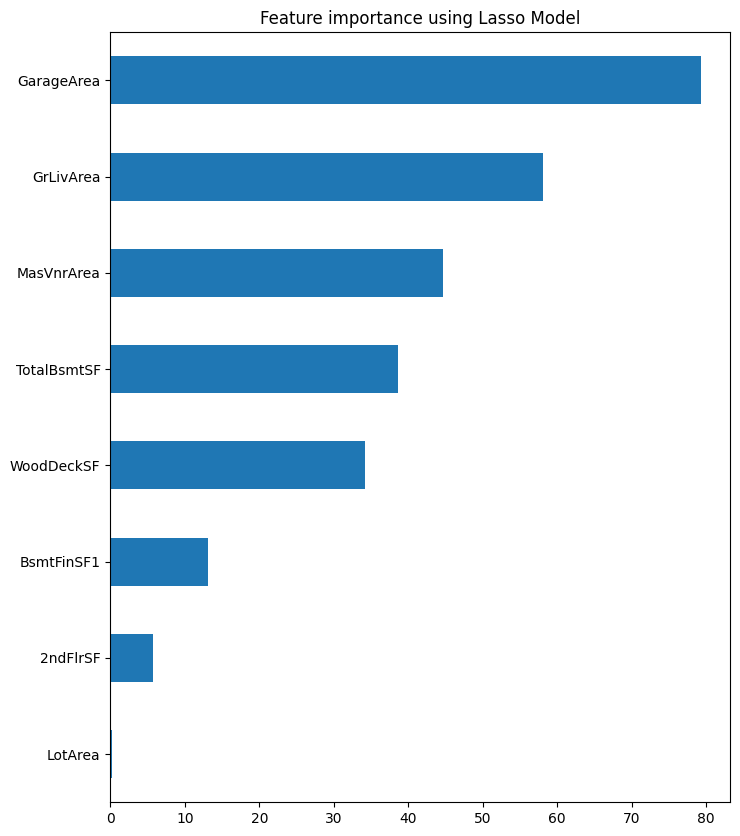

In [125]:
# plotting all positive  coefficients
import matplotlib.pyplot as plt

imp_coef = coef[coef>0].sort_values()
import matplotlib
plt.figure(figsize=(8.0, 10.0))
imp_coef.plot(kind = "barh")
plt.title("Feature importance using Lasso Model")

In [126]:
X[features_kept].head()

,LotArea,MasVnrArea,BsmtFinSF1,TotalBsmtSF,2ndFlrSF,GrLivArea,GarageArea,WoodDeckSF
Id,,,,,,,,
1,8450,196.0,706,856,854,1710,548,0
2,9600,0.0,978,1262,0,1262,460,298
3,11250,162.0,486,920,866,1786,608,0
4,9550,0.0,216,756,756,1717,642,0
5,14260,350.0,655,1145,1053,2198,836,192


In [ ]:
# features kept concatenated with target variable
pd.concat([X[features_kept], y], axis=1).sample(3)

,LotArea,MasVnrArea,BsmtFinSF1,TotalBsmtSF,2ndFlrSF,GrLivArea,GarageArea,WoodDeckSF,SalePrice
Id,,,,,,,,,
717,10800,0.0,0,718,978,2554,704,0,159500
132,12224,40.0,695,992,1032,2054,390,24,244000
529,9098,0.0,348,528,0,605,0,0,86000


In [130]:
# save features kept to csv
df= pd.concat([X[features_kept], y], axis=1)
df.to_csv("../data/features_kept1.csv")

In [ ]:
# تقسيم البيانات 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X[features_kept], y  ,test_size=.33, random_state=42)

## Optional 

In [148]:
from sklearn.feature_selection import SelectKBest, f_classif 


fit = SelectKBest(score_func=f_classif, k=10) # Example using f_classif
# bestfeatures = SelectKBest(score_func=chi2, k=5)
fit = fit.fit(X, y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
featureScores = pd.concat([dfcolumns, dfscores], axis=1)
featureScores.columns = ['Specs', 'Score']
print(featureScores.nlargest(10, 'Score'))

          Specs     Score
50        Isnew  6.901988
6   OverallQual  5.729183
46      MiscVal  3.756250
9     ExterQual  3.729438
24    GrLivArea  3.435110
2       LotArea  3.285852
31  KitchenQual  3.124488
11     BsmtQual  2.925698
27     FullBath  2.678847
36   GarageArea  2.583341
